# Titanic - Machine Learning from Disaster

**Goal:** Predict survival and reach **≥ 78.9%** Kaggle leaderboard accuracy  
**Project:** kaggle-titanic  

## 1. Setup & Project Initialization

In this section I will:
- Import required libraries
- Set random seed
- Define data paths and basic settings

In [4718]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization (optional for later EDA)
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import cross_val_score   
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/"


## 2. Load Data

In this section I will:

- Load the training dataset (`train.csv`)
- Load the test dataset (`test.csv`)
- Load the sample submission file (`gender_submission.csv`)
- Verify that the files are correctly loaded

In [4719]:
train_df = pd.read_csv(DATA_PATH + "train.csv")
test_df = pd.read_csv(DATA_PATH + "test.csv")
sample_submission = pd.read_csv(DATA_PATH + "gender_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Sample submission shape: (418, 2)


### 2.1 First Look at the Data

In this section I will:

- Display the first rows of the training dataset
- Display the first rows of the test dataset
- Check column names
- Confirm basic structure

In [4720]:
print("\nFirst 5 rows of training data:")
display(train_df.head())

print("\nFirst 5 rows of test data:")
display(test_df.head())


First 5 rows of training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



First 5 rows of test data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Data Quality Analysis

In this section I will:

- Check data types
- Identify missing values
- Measure percentage of missing values
- Check for duplicate rows

This will help decide:
- What to impute
- What to transform
- What to possibly drop

In [4721]:
train_df.info()

print("\nMissing values in training data:")
missing_train = train_df.isnull().sum().sort_values(ascending=False).head(5)
print(missing_train)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values in training data:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

In this section I will explore survival patterns based on:

- Sex
- Passenger Class (Pclass)
- Age
- Fare
- Family variables (SibSp, Parch)

The goal is to understand what factors influenced survival.

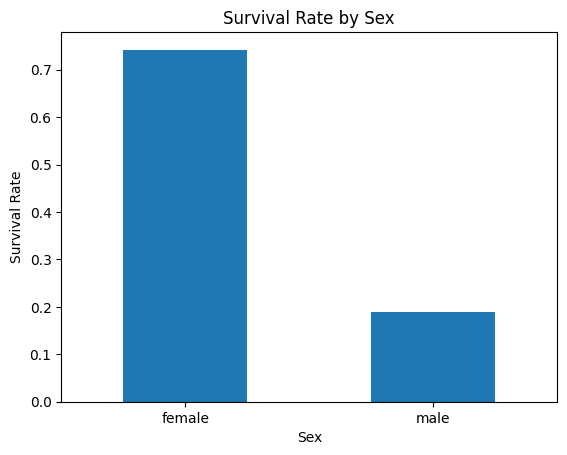

In [4722]:
survival_by_sex = train_df.groupby("Sex")["Survived"].mean()

plt.figure()
survival_by_sex.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

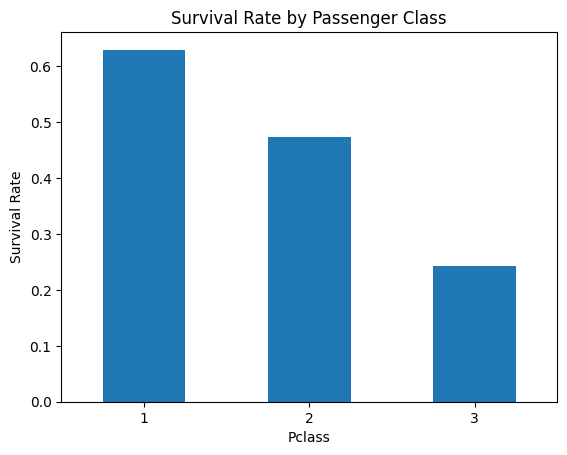

In [4723]:
survival_by_class = train_df.groupby("Pclass")["Survived"].mean()

plt.figure()
survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

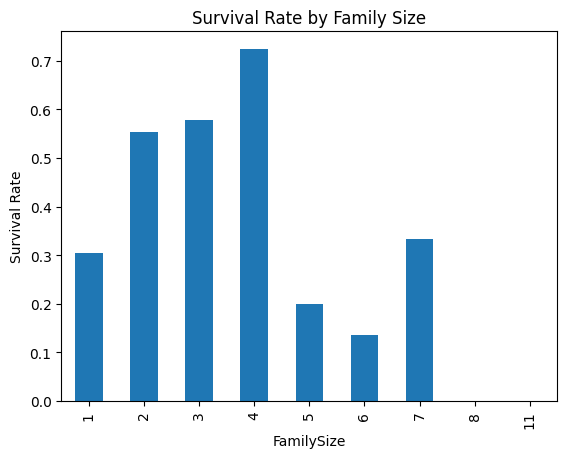

In [4724]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
survival_by_family = train_df.groupby("FamilySize")["Survived"].mean()

plt.figure()
survival_by_family.plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
plt.show()

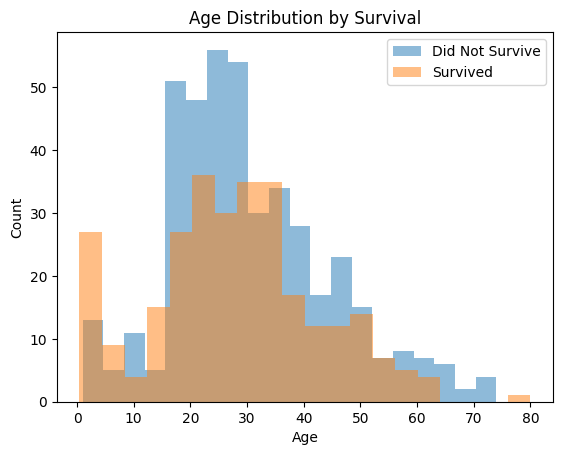

In [4725]:
plt.figure()

plt.hist(train_df[train_df["Survived"] == 0]["Age"].dropna(), bins=20, alpha=0.5, label="Did Not Survive")
plt.hist(train_df[train_df["Survived"] == 1]["Age"].dropna(), bins=20, alpha=0.5, label="Survived")

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()
correct = pd.read_csv(DATA_PATH + "submission_test.csv")



## 5. Feature Engineering

In this section I will:

- Create meaningful features based on EDA insights
- Handle missing values
- Extract information from existing columns
- Prepare the dataset for modeling

Feature engineering is critical for improving accuracy.

In [4726]:
for df in [train_df, test_df]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    # df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [4727]:
for df in [train_df, test_df]:
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace(['Dr', 'Rev', 'Major', 'Col', 'Don', 'Sir', 'Capt', 'Jonkheer'], 'Mr')
    df["Title"] = df["Title"].replace(['Mlle', 'Ms'], 'Miss')
    df["Title"] = df["Title"].replace(['Mme', 'Lady', 'Countess', 'Dona'], 'Mrs')
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    

In [4728]:
for df in [train_df, test_df]:
    df["Age"] = df.groupby("Title")["Age"].transform( lambda x: x.fillna(x.median()))
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

### 5.2 Encoding & Dropping Unnecessary Columns

In this section I will:

- Convert categorical variables into numeric format
- Drop columns that are not useful for prediction
- Prepare a clean dataset for modeling

Columns to drop:
- Name (already extracted Title)
- Ticket (too complex for now)
- Cabin (replaced by CabinKnown)
- PassengerId (not useful for training)

In [4729]:
passenger_id = test_df["PassengerId"]



for df in [train_df, test_df]:
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df["Embarked"] = df["Embarked"].fillna("S")
    df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
    df["Title"] = df["Title"].map({"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3}).fillna(0).astype(int)

    df["Fare_Per_Person"] = df["Fare"] / df["FamilySize"]
    df['FareLog']             = np.log1p(df['Fare'])          
    df['Fare_Per_Person_Log'] = np.log1p(df['Fare_Per_Person'])
    df['Age_Class']           = df['Age'] * df['Pclass']       
    df['Sex_x_Pclass']        = df['Sex'] * df['Pclass']       
    df['Age_Sex']             = df['Age'] * df['Sex']          
    df['Sex_Title']           = df['Sex'] * df['Title']        
    df['IsWoman_1st']         = ((df['Sex']==0) & (df['Pclass']==1)).astype(int)
    df['IsWoman_3st']         = ((df['Sex']==0) & (df['Pclass']==3)).astype(int)
    df['IsWoman']             = ((df['Sex']==0)).astype(int)
    df['IsBoy']               = ((df['Age']<15) & (df['Sex']==1)).astype(int)
    df['IsBoyAlone']     = ((df['Age'] < 15) & (df['FamilySize'] == 1)).astype(int)
    
    df.drop(["Name", "Ticket", "Cabin", "Parch", "SibSp", "PassengerId", "Fare", "Fare_Per_Person", "FamilySize"], axis=1, inplace=True)
    
train_df.head()

,Survived,Pclass,Sex,Age,Embarked,Title,HasCabin,FareLog,Fare_Per_Person_Log,Age_Class,Sex_x_Pclass,Age_Sex,Sex_Title,IsWoman_1st,IsWoman_3st,IsWoman,IsBoy,IsBoyAlone
0,0,3,0,22.0,0,0,0,2.110213,1.531476,66.0,0,0.0,0,0,1,1,0,0
1,1,1,1,38.0,1,2,1,4.280593,3.601186,38.0,1,38.0,2,0,0,0,0,0
2,1,3,1,26.0,0,1,0,2.188856,2.188856,78.0,3,26.0,1,0,0,0,0,0
3,1,1,1,35.0,0,2,1,3.990834,3.316003,35.0,1,35.0,2,0,0,0,0,0
4,0,3,0,35.0,0,0,0,2.202765,2.202765,105.0,0,0.0,0,0,1,1,0,0


In [4730]:
y_train = train_df["Survived"]
X_train = train_df.drop("Survived", axis=1)
X_test = test_df

model = GradientBoostingClassifier(
    n_estimators    = 200, 
    learning_rate   = 0.01,
    max_depth       = 3,
    max_features    = 'sqrt',
    random_state    = 42
)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
print("Mean CV accuracy:", scores.mean())


Mean CV accuracy: 0.8125792480070302


## 6. create submission

In [4731]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": preds
})

submission.to_csv("../output/submissions/submission.csv", index=False)

print("Submission saved to:", "../output/submissions/submission.csv")
correct = pd.read_csv(DATA_PATH + "submission_test.csv")

# Compare predictions
score = (correct["Survived"] == submission["Survived"]).mean()
print("Test set accuracy:", score)

submission.head()

Submission saved to: ../output/submissions/submission.csv
Test set accuracy: 0.7918660287081339


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## 7. simple diagram

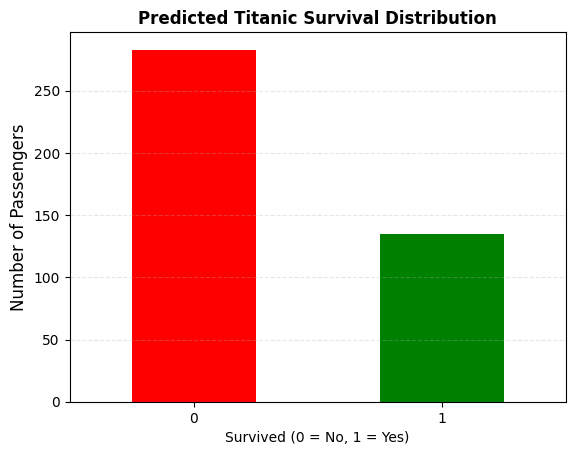

In [4732]:
survival_counts = submission["Survived"].value_counts()

survival_counts.plot(kind="bar", color=["red", "green"])
plt.title("Predicted Titanic Survival Distribution", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks(rotation=0)
plt.show()